<a href="https://colab.research.google.com/github/PLONTZNathan/MachineLearning_Assignment2/blob/main/TASK2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.base import clone
import importlib
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor


In [2]:
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/MyDrive')
import utils
importlib.reload(utils)
from utils import plot_y_yhat,clean_train_data,error_metric

Mounted at /content/drive


In [3]:
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/train_data.csv'
train = pd.read_csv(file_path)
file_path_2 = '/content/drive/MyDrive/test_data.csv'
test = pd.read_csv(file_path_2)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**TASK 2: NON LINEAR MODELS**

TASK 2.1 DEVELOPMENT

In [4]:
train_clean=clean_train_data(train)

In [30]:
X = train_clean[['Age', 'Gender', 'Stage', 'TreatmentType']]
y = train_clean["SurvivalTime"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)  # 60/40
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # 20/20

print(f"  Train set: {len(X_train)} samples")
print(f"  Validation set: {len(X_val)} samples")
print(f"  Test set: {len(X_test)} samples\n")

X_train_cv, X_test_cv, y_train_cv, y_test_cv = train_test_split(X, y, test_size=0.2, random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

train_sizes = []
val_sizes = []

for train_index, val_index in kf.split(X_train_cv):
    train_sizes.append(len(train_index))
    val_sizes.append(len(val_index))

print("Cross-validation (5-fold) sizes:")
print(f"  Train folds: {np.mean(train_sizes):.1f} ± {np.std(train_sizes):.1f} samples on average")
print(f"  Validation folds: {np.mean(val_sizes):.1f} ± {np.std(val_sizes):.1f} samples on average")
print(f"  Test set: {len(X_test_cv)} samples\n")

  Train set: 96 samples
  Validation set: 32 samples
  Test set: 33 samples

Cross-validation (5-fold) sizes:
  Train folds: 102.4 ± 0.5 samples on average
  Validation folds: 25.6 ± 0.5 samples on average
  Test set: 33 samples



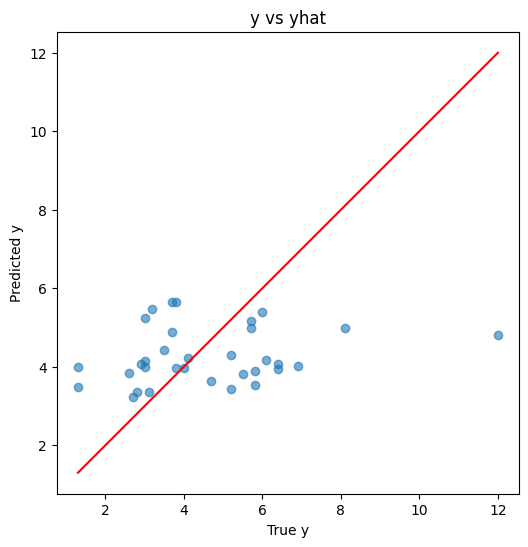

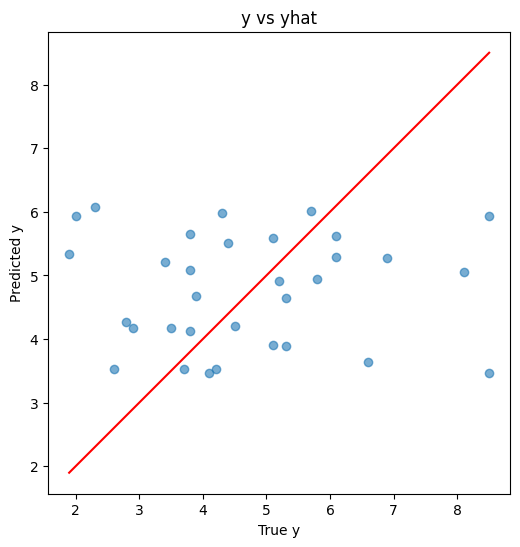

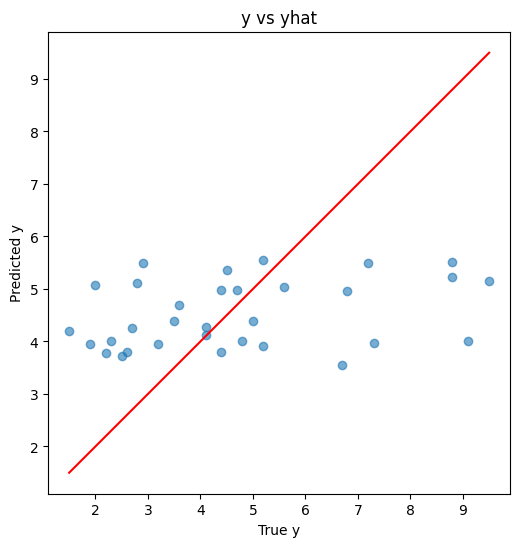

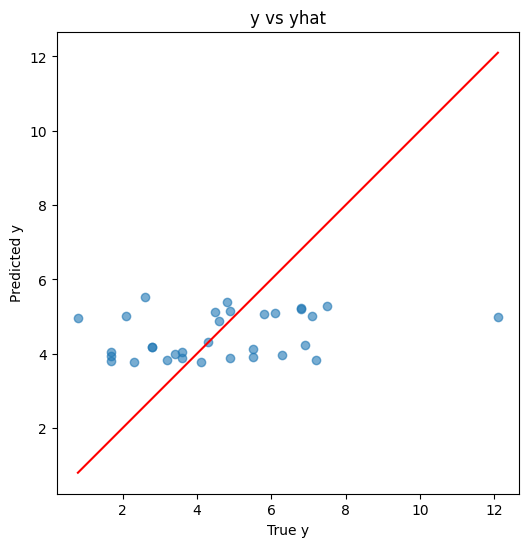

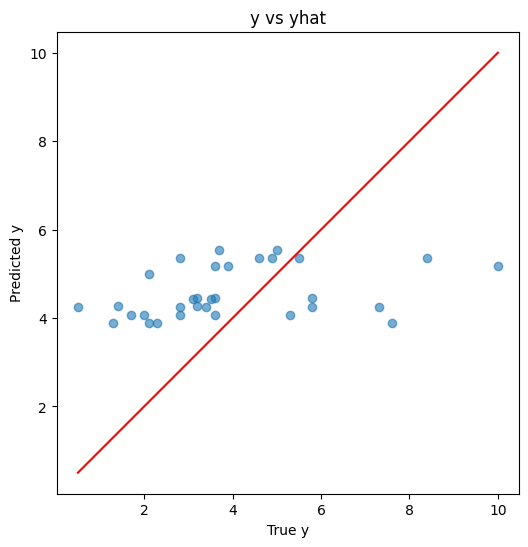

Baseline error_metric (5-fold CV): 4.345811652516245


In [31]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])
kf = KFold(n_splits=5, shuffle=True)
cv_scores = []
models = []

for train_idx, test_idx in kf.split(X):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    model = clone(pipeline)
    model.fit(X_tr, y_tr)

    y_hat = model.predict(X_te)
    score = error_metric(y_te.values, y_hat, c=0)
    cv_scores.append(score)

    plot_y_yhat(y_te, y_hat)

    models.append(model)

print(f"Baseline error_metric ({kf.n_splits}-fold CV):", np.mean(cv_scores))

In [32]:
# Polynomial Regression
# best_model_fitted, best_degree, cv_scores (dict).

def select_polynomial_model(
    X_tr, y_tr,
    degrees=[1, 2, 3, 4, 5],
    n_splits=5,
    shuffle=True
):

    cv_scores = {}
    best_score = np.inf
    best_degree = None
    best_model = None

    for d in degrees:
        # Pipeline: standardizzazione -> espansione polinomiale -> regressione lineare
        pipe_poly = Pipeline([
            ("scaler", StandardScaler()),
            ("poly", PolynomialFeatures(degree=d, include_bias=False)),
            ("lin", LinearRegression())
        ])

        kfold = KFold(n_splits=n_splits, shuffle=shuffle)

        # out-of-fold predictions sul training
        y_tr_oof = cross_val_predict(pipe_poly, X_tr, y_tr, cv=kfold)

        # tua metrica (es. MSE)
        cmse_cv = error_metric(y_tr, y_tr_oof,c=0)
        cv_scores[d] = cmse_cv

        # tiene traccia del modello migliore
        if cmse_cv < best_score:
            best_score = cmse_cv
            best_degree = d
            # rifitta sul training completo
            best_model = pipe_poly.fit(X_tr, y_tr)

    return best_model, best_degree, cv_scores




In [33]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2)

# Polynomial Regression
best_poly_model, best_degree, poly_cv_scores = select_polynomial_model(
    X_tr, y_tr,
    degrees=[1, 2, 3, 4, 5,6,7,8],
    n_splits=5
)
print("Miglior grado polinomiale:", best_degree)
print("CV scores per grado:", poly_cv_scores)

y_pred_poly = best_poly_model.predict(X_te)
test_err_poly = error_metric(y_te, y_pred_poly,c=0)


Miglior grado polinomiale: 1
CV scores per grado: {1: np.float64(4.848489838029833), 2: np.float64(5.125722765396825), 3: np.float64(6.020285645520358), 4: np.float64(20.923293696926386), 5: np.float64(503.8084131352831), 6: np.float64(79796.43402598993), 7: np.float64(33404219.569626026), 8: np.float64(541970454282.57544)}


In [34]:

def plot_y_vs_yhat(y_true, y_pred, title="y vs y_hat"):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.6)

    # Diagonale perfetta y = y_hat
    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.xlabel("True y")
    plt.ylabel("Predicted y")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


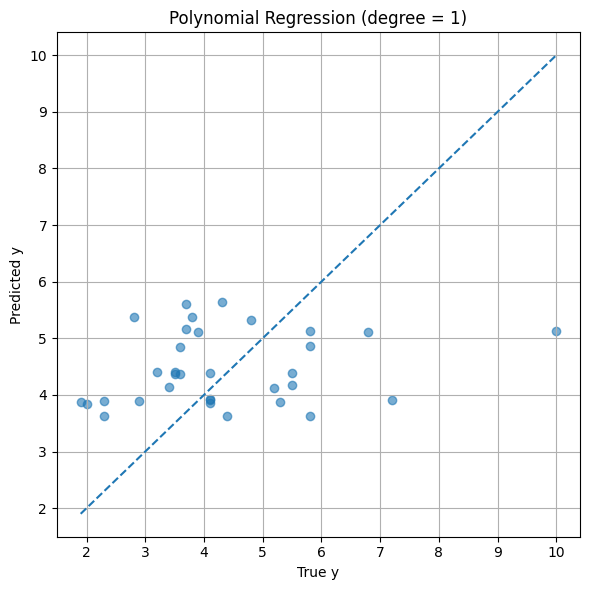

In [35]:
plot_y_vs_yhat(
    y_te,
    y_pred_poly,
    title=f"Polynomial Regression (degree = {best_degree})"
)


In [36]:
# k-Nearest Neighbors
# Seleziona il miglior k (e schema di pesi) per kNN tramite k-fold CV.
# Restituisce: best_model_fitted, best_params (dict), cv_scores (dict).
def select_knn_model(
    X_tr, y_tr,
    k_list=[3, 5, 7, 9, 11],
    weights_list=["uniform", "distance"],
    n_splits=5,
    shuffle=True
):

    cv_scores = {}
    best_score = np.inf
    best_params = None
    best_model = None

    for k in k_list:
        for w in weights_list:
            pipe_knn = Pipeline([
                ("scaler", StandardScaler()),
                ("knn", KNeighborsRegressor(
                    n_neighbors=k,
                    weights=w
                ))
            ])

            kfold = KFold(n_splits=n_splits, shuffle=shuffle)

            # out-of-fold predictions sul training
            y_tr_oof = cross_val_predict(pipe_knn, X_tr, y_tr, cv=kfold)

            cmse_cv = error_metric(y_tr, y_tr_oof,c=0)
            cv_scores[(k, w)] = cmse_cv

            if cmse_cv < best_score:
                best_score = cmse_cv
                best_params = {"k": k, "weights": w}
                best_model = pipe_knn.fit(X_tr, y_tr)

    return best_model, best_params, cv_scores



In [37]:
# k-Nearest Neighbors
best_knn_model, best_knn_params, knn_cv_scores = select_knn_model(
    X_tr, y_tr,
    k_list=[3,4,5,6,7,8, 9,10,11,12,13,14,15,16],
    weights_list=["uniform", "distance"],
    n_splits=5
)
print("Miglior set di iperparametri kNN:", best_knn_params)
print("CV scores per (k, weights):", knn_cv_scores)


y_pred_knn  = best_knn_model.predict(X_te)
test_err_knn  = error_metric(y_te, y_pred_knn,c=0)

Miglior set di iperparametri kNN: {'k': 16, 'weights': 'uniform'}
CV scores per (k, weights): {(3, 'uniform'): np.float64(5.551909722222223), (3, 'distance'): np.float64(7.091186825518403), (4, 'uniform'): np.float64(5.5990576171874995), (4, 'distance'): np.float64(6.368599626113127), (5, 'uniform'): np.float64(5.636931250000001), (5, 'distance'): np.float64(6.173615204296513), (6, 'uniform'): np.float64(5.123014322916667), (6, 'distance'): np.float64(5.402182262285327), (7, 'uniform'): np.float64(5.359987244897959), (7, 'distance'): np.float64(6.157470215551939), (8, 'uniform'): np.float64(4.896724853515625), (8, 'distance'): np.float64(5.808128627199791), (9, 'uniform'): np.float64(4.852146026234568), (9, 'distance'): np.float64(6.0009630729533505), (10, 'uniform'): np.float64(5.0436703125), (10, 'distance'): np.float64(5.958581311746739), (11, 'uniform'): np.float64(5.037770532024793), (11, 'distance'): np.float64(5.71045756931238), (12, 'uniform'): np.float64(4.888143988715278), (1

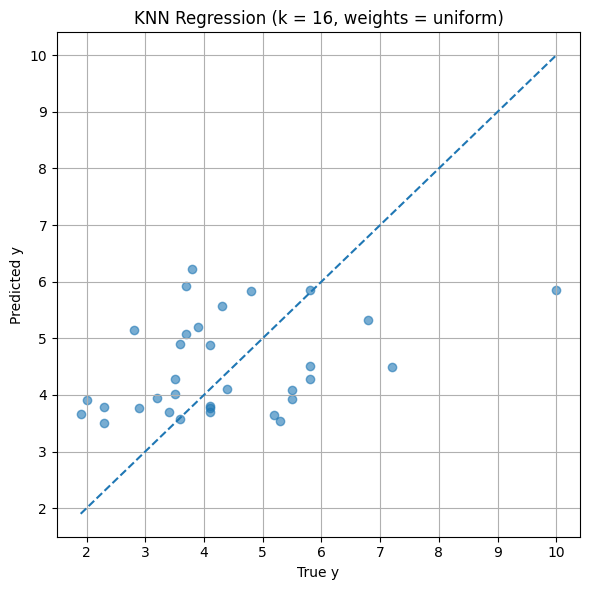

In [51]:
plot_y_vs_yhat(
    y_te,
    y_pred_knn,
    title=f"KNN Regression (k = {best_knn_params['k']}, weights = {best_knn_params['weights']})"
)


**TASK 2.2**

In [39]:
#Lista error su ogni fold
def evaluate_model_cv(model, X, y, n_splits=5, shuffle=True):

    kf = KFold(n_splits=n_splits, shuffle=shuffle)
    fold_errors = []

    for train_idx, test_idx in kf.split(X):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        m = clone(model)
        m.fit(X_tr, y_tr)

        y_hat = m.predict(X_te)
        err = error_metric(y_te.values, y_hat, c=0)
        fold_errors.append(err)

    return fold_errors


In [40]:
# Baseline model
baseline_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

errors_baseline = evaluate_model_cv(baseline_model, X, y)

# Polynomial model (best already selected)
errors_poly = evaluate_model_cv(best_poly_model, X, y)

# KNN model (best already selected)
errors_knn = evaluate_model_cv(best_knn_model, X, y)


In [49]:
def summarize_errors(error_list):
    return {
        "min": np.min(error_list),
        "max": np.max(error_list),
        "mean": np.mean(error_list),
        "std": np.std(error_list)
    }

summary_df = pd.DataFrame({
    "Baseline (Linear)": summarize_errors(errors_baseline),
    f"Polynomial (deg={best_degree})": summarize_errors(errors_poly),
    f"KNN (k={best_knn_params['k']}, w={best_knn_params['weights']})": summarize_errors(errors_knn)
}).T

summary_df


,min,max,mean,std
Baseline (Linear),2.573919,6.636617,4.293187,1.418830
Polynomial (deg=1),2.694258,6.879562,4.232694,1.450239
"KNN (k=16, w=uniform)",3.668434,5.126122,4.389245,0.590191


In [47]:
#KNN
X_test = test[['Age', 'Gender', 'Stage', 'TreatmentType']]

y_test_pred = np.zeros(len(X_test))
for model in models:
    y_test_pred += best_knn_model.predict(X_test)
y_test_pred /= len(models)
submission_filename = "Nonlinear-submission-01.csv"

submission = pd.DataFrame({
    'id': test.index,
    0: y_test_pred
})

submission.to_csv(submission_filename, index=False)
print("Saved:", submission_filename)
submission.head()


Saved: Nonlinear-submission-01.csv


,id,0
0,0,5.18750
1,1,3.50000
2,2,3.70000
3,3,4.96875
4,4,3.83750


In [48]:
#Polynomial
X_test = test[['Age', 'Gender', 'Stage', 'TreatmentType']]

y_test_pred = np.zeros(len(X_test))
for model in models:
    y_test_pred += best_poly_model.predict(X_test)
y_test_pred /= len(models)
submission_filename = "Polynomial-submission-01.csv"

submission = pd.DataFrame({
    'id': test.index,
    0: y_test_pred
})

submission.to_csv(submission_filename, index=False)
print("Saved:", submission_filename)
submission.head()

Saved: Polynomial-submission-01.csv


,id,0
0,0,5.639081
1,1,4.380415
2,2,3.875310
3,3,5.371859
4,4,4.373735
